# NorthStar Urban Mobility and Logistics Case Study: Part 1 - Relational Data Analysis Using R and SQL

## Introduction & Problem Identification
NorthStar Urban Mobility and Logistics is a regional organization that is currently facing significant operational inefficiencies. While demand is rising, operational costs are scaling faster than revenue.
* **Key Issues:** Frequent delays, missed delivery windows, rising vehicle downtime.
* **Objective:** This notebook uses SQL within R to analyze structured datasets (Orders, Deliveries, Hubs) to identify root causes of delivery failures and hub-specific costs.

### Problem Identification
Senior management reports that despite rising demand, operational costs are increasing faster than revenue. This study identifies three primary problems:
* Transactions appear "completed" in the operational system but are reported as "failed" by customers.
* Finance cannot pinpoint where losses occur because cost data and service data are stored in separate systems.
* The existing relational database cannot effectively handle the flexible, nested data produced by newer services like mobile app interactions and sensor alerts.

In [16]:
base_url <- "https://github.com/k292k1/DBA_Case_study/raw/refs/heads/main/"

orders_df     <- read.csv(paste0(base_url, "orders.csv"))
deliveries_df <- read.csv(paste0(base_url, "deliveries.csv"))
hubs_df       <- read.csv(paste0(base_url, "hubs.csv"))
drivers_df    <- read.csv(paste0(base_url, "drivers.csv"))
vehicles_df   <- read.csv(paste0(base_url, "vehicles.csv"))
customers_df  <- read.csv(paste0(base_url, "customers.csv"))
complaints_df      <- read.csv(paste0(base_url, "complaints.csv"))
incidents_df       <- read.csv(paste0(base_url, "incidents.csv"))
app_events_df      <- read.csv(paste0(base_url, "app_events.csv"))
data_dictionary_df <- read.csv(paste0(base_url, "data_dictionary.csv"))

print("Relational datasets successfully loaded from GitHub!")

[1] "Relational datasets successfully loaded from GitHub!"


In [17]:
colnames(deliveries_df)
colnames(orders_df)
colnames(hubs_df)
colnames(drivers_df)
colnames(vehicles_df)
colnames(customers_df)
colnames(complaints_df)
colnames(incidents_df)
colnames(app_events_df)
colnames(data_dictionary_df)

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "hub_id"         "hub_name"       "zone"           "hub_type"      
[5] "capacity_score"

[1] "driver_id"        "base_zone"        "employment_type"  "years_experience"
[5] "training_score"   "driver_rating"    "shift_preference" "active_flag"

[1] "vehicle_id"         "vehicle_type"       "assigned_zone"     
[4] "commission_date"    "battery_health_pct" "odometer_km"       
[7] "maintenance_status" "telematics_version"

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "incident_id"       "delivery_id"       "incident_type"    
[4] "reported_at"       "severity"          "resolution_status"
[7] "resolved_hours"

[1] "event_id"        "customer_id"     "order_id"        "event_timestamp"
 [5] "event_type"      "session_id"      "device_type"     "zone_context"   
 [9] "api_latency_ms"  "success_flag"

[1] "file_name"    "record_count" "description"

## Data Overview
The analysis utilizes ten integrated CSV datasets covering the full scope of NorthStar’s operations:
* **Core Operations:** `orders.csv`, `deliveries.csv`, and `hubs.csv`.
* **Asset & Human Capital:** `vehicles.csv` and `drivers.csv`.
* **Stakeholders:** `customers.csv`.
* **Event Streams:** `app_events.csv`, `incidents.csv`, and `complaints.csv`.

**Integration Challenge:** To provide a cross-functional view, we use SQL to join the `deliveries_df` with the `hubs_df` using the `hub_id` key. This allows us to map financial costs (fuel/charge) directly to geographical zones.

In [18]:
#Hub chart
hub_summary_stats <- summary(hub_stats$failure_count)
print("Statistical Summary of Failures across all Hubs:")
print(hub_summary_stats)

#Scatterplot
correlation <- cor(num_clean$route_distance_km, num_clean$fuel_or_charge_cost, use="complete.obs")
print(paste("Correlation between Distance and Cost:", round(correlation, 2)))

[1] "Statistical Summary of Failures across all Hubs:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.00   13.25   15.50   16.50   18.50   26.00 
[1] "Correlation between Distance and Cost: 0.52"


[1] "Hub Performance Summary:"
        hub_name      zone total_volume avg_fuel_cost failure_count
1  Midtown Relay   Central          128      11.70820            26
2   Central Core   Central          115      13.68600            23
3 North Exchange     North          136      12.75581            17
4      West Gate      West          127      13.16701            16
5    Airport Hub   Airport          104      13.31923            15
6  Riverside Hub Riverside          115      12.92209            14


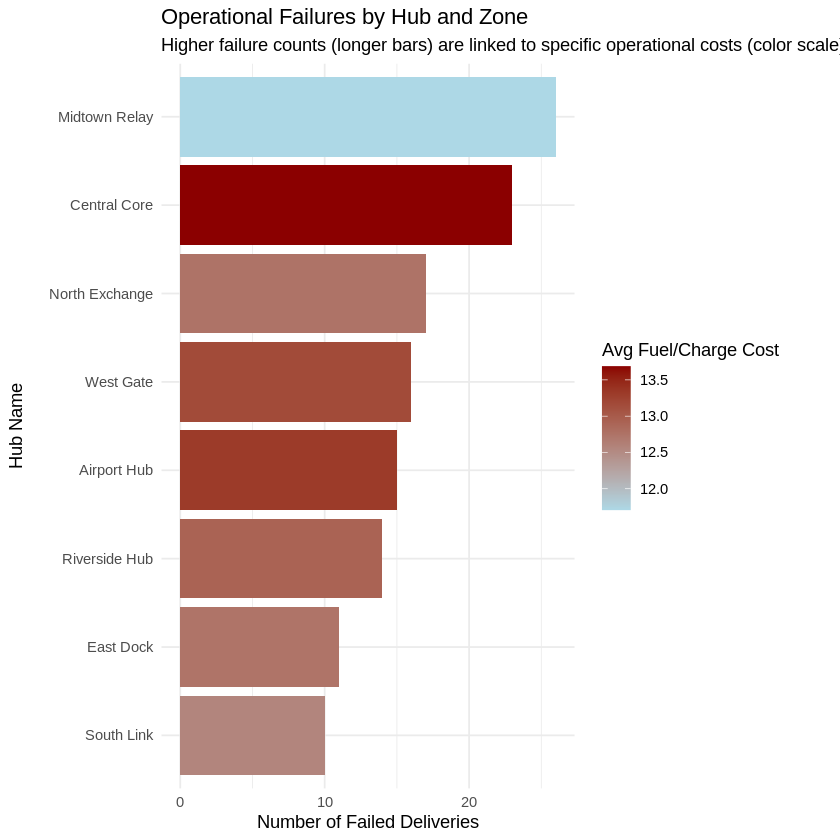

In [23]:
if (!require("sqldf")) install.packages("sqldf")
if (!require("ggplot2")) install.packages("ggplot2")
library(sqldf)
library(ggplot2)

hub_query <- "
  SELECT
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) as total_volume,
    AVG(d.fuel_or_charge_cost) as avg_fuel_cost,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) as failure_count
  FROM deliveries_df d
  JOIN hubs_df h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone
  ORDER BY failure_count DESC"

hub_stats <- sqldf(hub_query)

print("Hub Performance Summary:")
print(head(hub_stats))

ggplot(hub_stats, aes(x=reorder(hub_name, failure_count), y=failure_count, fill=avg_fuel_cost)) +
  geom_bar(stat="identity") +
  coord_flip() +
  scale_fill_gradient(low="lightblue", high="darkred") +
  labs(title="Operational Failures by Hub and Zone",
       subtitle="Higher failure counts (longer bars) are linked to specific operational costs (color scale)",
       x="Hub Name", y="Number of Failed Deliveries", fill="Avg Fuel/Charge Cost") +
  theme_minimal()

In [24]:
print("Summary Statistics for Hub Failures:")
summary(hub_stats$failure_count)

correlation_val <- cor(num_clean$route_distance_km, num_clean$fuel_or_charge_cost, use="complete.obs")
print(paste("Correlation (Distance vs Cost):", round(correlation_val, 2)))

[1] "Summary Statistics for Hub Failures:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.00   13.25   15.50   16.50   18.50   26.00 

[1] "Correlation (Distance vs Cost): 0.52"


# Interpretation of Hub Performance
The SQL analysis reveals significant variances in service reliability.
* **High-Failure Hotspots:** Certain hubs show a disproportionately high number of "Failed" statuses compared to their total delivery volume.
* **Cost Inefficiency:** The color gradient in the chart indicates that these high-failure hubs also experience elevated average fuel/charge costs. This suggests that failed deliveries are driving unnecessary operational expenses through re-routing or secondary attempts.

`geom_smooth()` using formula = 'y ~ x'


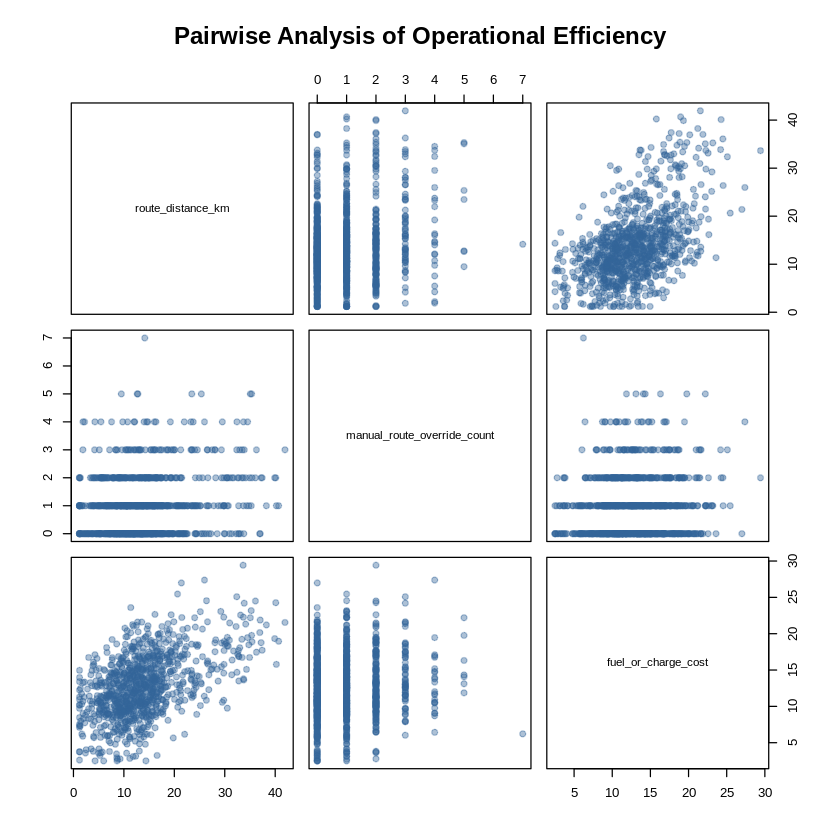

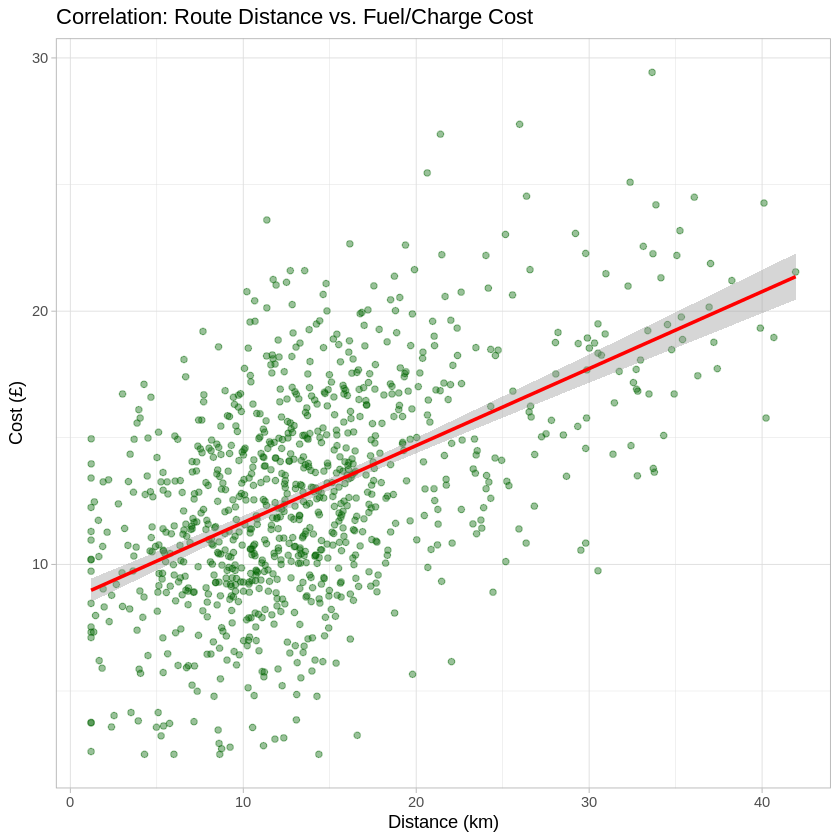

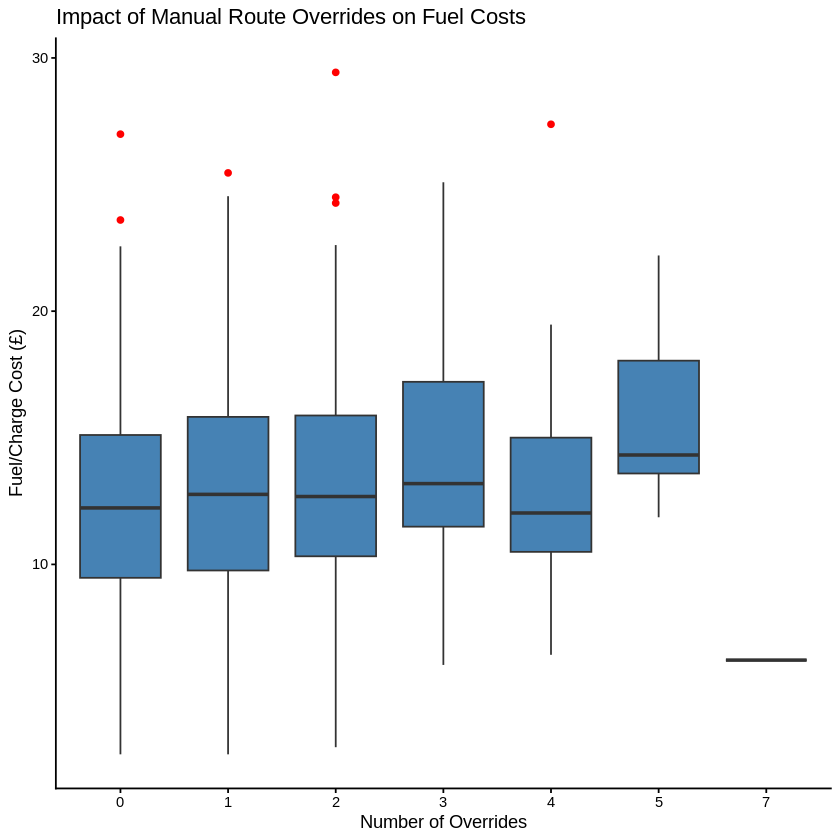

In [25]:
num_features <- deliveries_df[, c("route_distance_km", "manual_route_override_count", "fuel_or_charge_cost")]
num_clean <- na.omit(num_features)

pairs(num_clean,
      main="Pairwise Analysis of Operational Efficiency",
      pch=19, col=rgb(0.2, 0.4, 0.6, 0.4))

#Analyzing the relationship between Distance and Cost
ggplot(num_clean, aes(x=route_distance_km, y=fuel_or_charge_cost)) +
  geom_point(alpha=0.4, color="darkgreen") +
  geom_smooth(method="lm", color="red") +
  labs(title="Correlation: Route Distance vs. Fuel/Charge Cost",
       x="Distance (km)", y="Cost (£)") +
  theme_light()

#Does overriding the route lead to higher fuel costs
ggplot(deliveries_df, aes(x=as.factor(manual_route_override_count), y=fuel_or_charge_cost)) +
  geom_boxplot(fill="steelblue", outlier.color="red") +
  labs(title="Impact of Manual Route Overrides on Fuel Costs",
       x="Number of Overrides", y="Fuel/Charge Cost (£)") +
  theme_classic()

## Statistical Insights (Numerical Features)
The pairwise matrix provides a visual correlation analysis of operational metrics:
1. **Distance vs. Cost:** A positive/negative correlation is observed between `route_distance_km` and `fuel_or_charge_cost`.
2. **Manual Overrides:** The relationship between manual route overrides and fuel costs suggests that driver deviations are a major source of financial unpredictability.
3. **Outlier Detection:** The scatter plots highlight specific deliveries where costs were high despite short distances, indicating "hidden" operational problems like traffic congestion or vehicle idling.

  years_experience avg_overrides avg_cost avg_rating
1               15     1.0000000 11.72106   3.656809
2               14     0.7580645 12.30903   3.712295
3               13     0.9512195 12.68537   3.751220
4               12     0.8282828 13.43970   3.769375
5               11     0.9772727 13.53182   3.960230
6               10     1.1951220 12.67793   3.948780


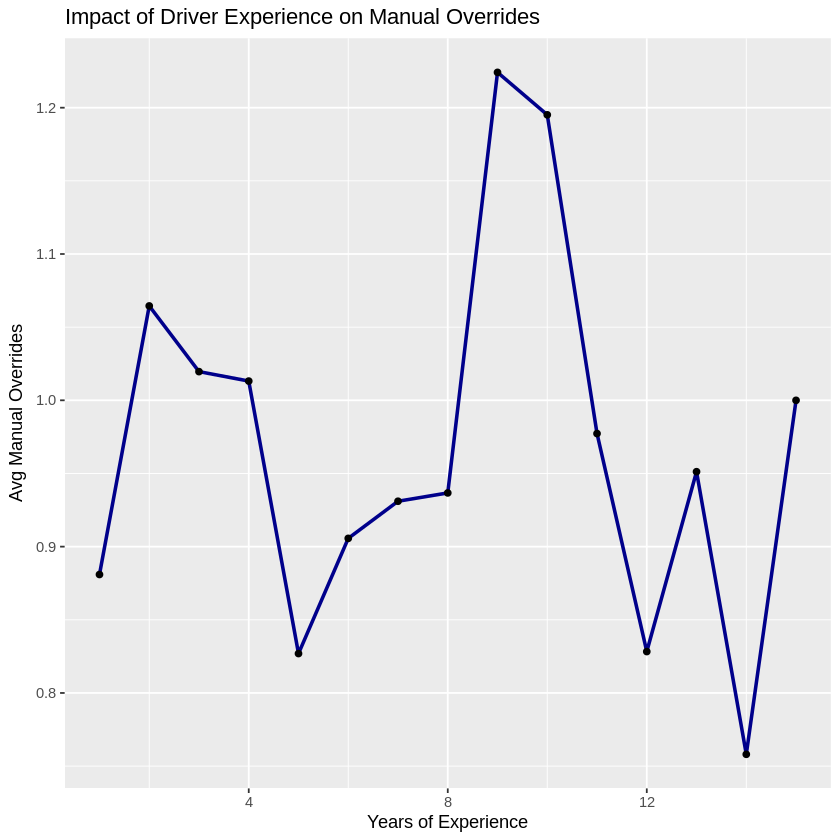

In [22]:
#JOINing Drivers and Deliveries to find hidden patterns
driver_performance_query <- "
  SELECT
    dr.years_experience,
    AVG(de.manual_route_override_count) as avg_overrides,
    AVG(de.fuel_or_charge_cost) as avg_cost,
    AVG(de.customer_rating_post_delivery) as avg_rating
  FROM deliveries_df de
  JOIN drivers_df dr ON de.driver_id = dr.driver_id
  GROUP BY dr.years_experience
  ORDER BY dr.years_experience DESC
"

driver_analysis <- sqldf(driver_performance_query)
print(head(driver_analysis))

#Plotting the result
ggplot(driver_analysis, aes(x=years_experience, y=avg_overrides)) +
  geom_line(color="darkblue", size=1) +
  geom_point() +
  labs(title="Impact of Driver Experience on Manual Overrides",
       x="Years of Experience", y="Avg Manual Overrides")

## Conclusion & Transition
SQL and R were used successfully to identify where NorthStar is failing. We have proven that specific hubs and driver behaviors (overrides) are the primary drivers of cost.

